In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("student_dropout_prediction_5000.csv")
df.head(6)

,Student_ID,Name,Age,Gender,Marital_Status,Previous_GPA,GPA,Failed_Courses,Attendance_Rate,Tuition_Fees_Up_to_Date,Scholarship,Family_Income,Financial_Stress,LMS_Engagement,Quiz_Attempts,Assignment_Completion_Rate,Study_Hours_Per_Week,Dropout
0,STU100001,Mahin Islam,20.0,Female,Single,3.30,3.19,0,75.8,Yes,Yes,17616.0,Low,86.5,7.0,49.4,5.7,No
1,STU100002,Mariya Sultana,20.0,Female,Married,3.47,3.40,0,83.9,Yes,No,73251.0,Medium,95.5,7.0,82.3,17.1,No
2,STU100003,Sumaiya Islam,21.0,Female,Single,2.96,2.95,1,88.5,No,No,105200.0,Low,98.1,6.0,83.6,10.9,No
3,STU100004,Nusrat Khan,22.0,Male,Single,3.27,3.18,0,69.2,Yes,No,102895.0,Low,78.8,6.0,68.7,10.6,No
4,STU100005,Mahin Akter,18.0,Male,Single,2.88,2.79,0,88.5,Yes,No,60270.0,Low,82.0,9.0,75.7,14.7,No
5,STU100006,Sadia Ahmed,21.0,Male,Single,3.22,3.73,0,73.4,No,No,43111.0,High,84.2,4.0,65.0,8.3,No


In [3]:
df.isnull().sum()

Student_ID                     0
Name                           0
Age                           50
Gender                         0
Marital_Status                 0
Previous_GPA                   0
GPA                           50
Failed_Courses                 0
Attendance_Rate               50
Tuition_Fees_Up_to_Date        0
Scholarship                    0
Family_Income                 50
Financial_Stress               0
LMS_Engagement                50
Quiz_Attempts                 50
Assignment_Completion_Rate     0
Study_Hours_Per_Week           0
Dropout                        0
dtype: int64

In [4]:
#replace null values with mean of the column
 
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [5]:
#now again check for null values
df.isnull().sum()

Student_ID                    0
Name                          0
Age                           0
Gender                        0
Marital_Status                0
Previous_GPA                  0
GPA                           0
Failed_Courses                0
Attendance_Rate               0
Tuition_Fees_Up_to_Date       0
Scholarship                   0
Family_Income                 0
Financial_Stress              0
LMS_Engagement                0
Quiz_Attempts                 0
Assignment_Completion_Rate    0
Study_Hours_Per_Week          0
Dropout                       0
dtype: int64

In [6]:
df.dtypes

Student_ID                     object
Name                           object
Age                           float64
Gender                         object
Marital_Status                 object
Previous_GPA                  float64
GPA                           float64
Failed_Courses                  int64
Attendance_Rate               float64
Tuition_Fees_Up_to_Date        object
Scholarship                    object
Family_Income                 float64
Financial_Stress               object
LMS_Engagement                float64
Quiz_Attempts                 float64
Assignment_Completion_Rate    float64
Study_Hours_Per_Week          float64
Dropout                        object
dtype: object

In [7]:
# change dropout column to  numeric values
df['Dropout'] = df['Dropout'].map({'Yes': 1, 'No': 0})

In [8]:
df.head(10)

,Student_ID,Name,Age,Gender,Marital_Status,Previous_GPA,GPA,Failed_Courses,Attendance_Rate,Tuition_Fees_Up_to_Date,Scholarship,Family_Income,Financial_Stress,LMS_Engagement,Quiz_Attempts,Assignment_Completion_Rate,Study_Hours_Per_Week,Dropout
0,STU100001,Mahin Islam,20.0,Female,Single,3.30,3.19,0,75.8,Yes,Yes,17616.0,Low,86.5,7.0,49.4,5.7,0
1,STU100002,Mariya Sultana,20.0,Female,Married,3.47,3.40,0,83.9,Yes,No,73251.0,Medium,95.5,7.0,82.3,17.1,0
2,STU100003,Sumaiya Islam,21.0,Female,Single,2.96,2.95,1,88.5,No,No,105200.0,Low,98.1,6.0,83.6,10.9,0
3,STU100004,Nusrat Khan,22.0,Male,Single,3.27,3.18,0,69.2,Yes,No,102895.0,Low,78.8,6.0,68.7,10.6,0
4,STU100005,Mahin Akter,18.0,Male,Single,2.88,2.79,0,88.5,Yes,No,60270.0,Low,82.0,9.0,75.7,14.7,0
5,STU100006,Sadia Ahmed,21.0,Male,Single,3.22,3.73,0,73.4,No,No,43111.0,High,84.2,4.0,65.0,8.3,0
6,STU100007,Hasan Karim,28.0,Male,Single,3.09,3.13,1,80.9,No,No,75792.0,Medium,88.9,7.0,64.8,9.1,1
7,STU100008,Sakib Rahman,25.0,Female,Single,3.14,3.05,0,68.7,Yes,No,56503.0,Medium,66.8,6.0,58.2,7.1,0
8,STU100009,Mahin Islam,27.0,Male,Single,2.86,3.28,0,72.8,Yes,No,54993.0,Medium,67.4,4.0,64.8,6.0,0
9,STU100010,Nabila Ahmed,24.0,Female,Single,3.18,3.51,0,88.9,Yes,Yes,33679.0,Medium,94.5,6.0,75.1,17.6,0


In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
# Features and target
x = df.drop('Dropout', axis=1)
y = df['Dropout']
x = pd.get_dummies(x, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)

x_train_resampled, y_train_resampled = smote.fit_resample(
    x_train, y_train
)

print("After SMOTE:", Counter(y_train_resampled))

Before SMOTE: Counter({0: 3149, 1: 851})
After SMOTE: Counter({0: 3149, 1: 3149})


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_resampled)
x_test_scaled = scaler.transform(x_test)

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(x_train_scaled, y_train_resampled)

y_pred_lr = lr_model.predict(x_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.687
              precision    recall  f1-score   support

           0       0.87      0.70      0.77       768
           1       0.40      0.66      0.49       232

    accuracy                           0.69      1000
   macro avg       0.63      0.68      0.63      1000
weighted avg       0.76      0.69      0.71      1000



# class 0 to so we reduce it

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Scale data for Logistic Regression
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_resampled)
x_test_scaled = scaler.transform(x_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

results = []

# Train each model
for name, model in models.items():

    # Logistic Regression uses scaled data
    if name == "Logistic Regression":
        model.fit(x_train_scaled, y_train_resampled)
        y_pred = model.predict(x_test_scaled)
    
    # Other models use original SMOTE data
    else:
        model.fit(x_train_resampled, y_train_resampled)
        y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "F1-Score": round(f1, 2)
    })

# Comparison table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

print("Model Comparison Leaderboard:")
print(results_df.to_string(index=False))

Model Comparison Leaderboard:
              Model  Accuracy (%)  F1-Score
Logistic Regression          68.7      0.49
      Random Forest          77.5      0.45
      Decision Tree          70.5      0.42
            XGBoost          76.6      0.41


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


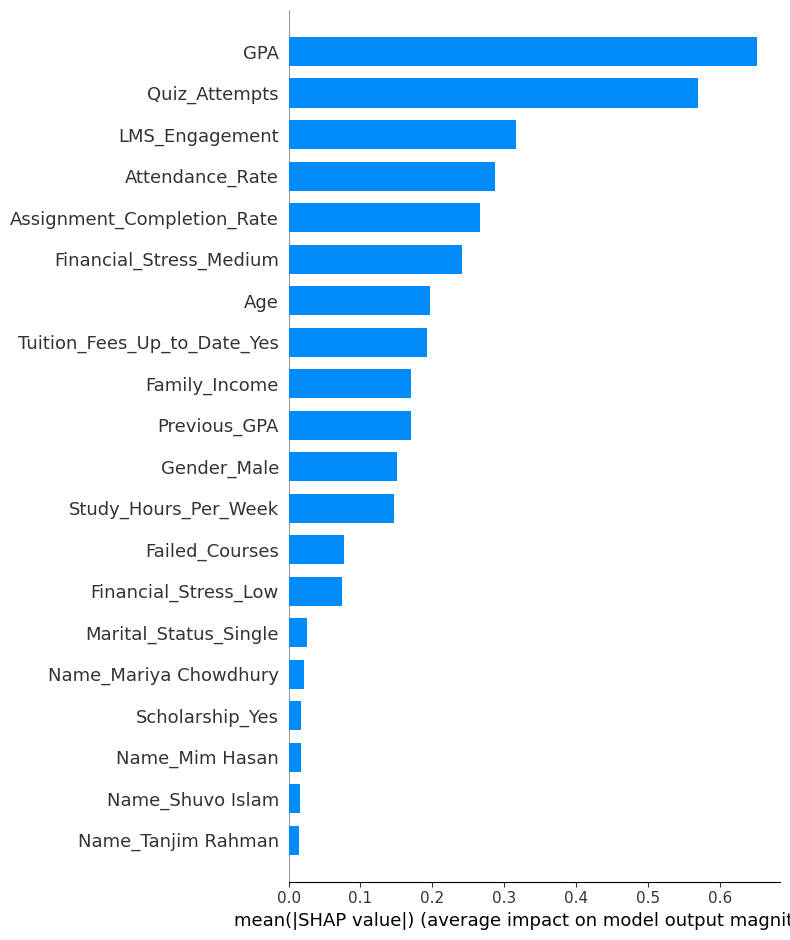

In [12]:
import shap
import matplotlib.pyplot as plt
import numpy as np

 

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(x_test)

# Handle different SHAP versions
if isinstance(shap_values, list):
    # Older SHAP versions
    shap.summary_plot(
        shap_values[1],
        x_test,
        plot_type="bar"
    )

elif len(shap_values.shape) == 3:
    # Newer SHAP versions
    shap.summary_plot(
        shap_values[:, :, 1],
        x_test,
        plot_type="bar"
    )

else:
    # Binary classification in newer SHAP versions
    shap.summary_plot(
        shap_values,
        x_test,
        plot_type="bar"
    )

In [20]:
# =========================================================
# 🚨 AUTOMATED STUDENT DROPOUT ALERT SYSTEM
# AUTO DETECT TOP 3 HIGH-RISK STUDENTS
# SHAP + DYNAMIC EMAIL ROUTING + EMAIL
# =========================================================

import numpy as np
import smtplib
import time

from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart


# =========================================================
# 1. EMAIL SETTINGS
# =========================================================

SENDER_EMAIL = "abdullahmahiner@gmail.com"

# Gmail App Password - 16 digit password
APP_PASSWORD = "lgju kfgv dxtq lyye"


# =========================================================
# 2. RECEIVER EMAILS
# =========================================================

ADVISOR_EMAIL = "abdullah2305341504@diu.edu.bd"
ACCOUNTS_EMAIL = "mahinmahin9696@gmail.com"
STUDENT_AFFAIRS_EMAIL = "abdullahmahin0202@gmail.com"


# =========================================================
# 3. START SYSTEM
# =========================================================

print("=" * 50)
print("🚨 AUTOMATED ALERT SYSTEM STARTED")
print("=" * 50)


# =========================================================
# 4. FIND ALL HIGH-RISK STUDENTS
# =========================================================

dropout_indices = np.where(y_pred == 1)[0]

print()
print("Total High-Risk Students:", len(dropout_indices))


if len(dropout_indices) == 0:

    print("✅ No high-risk students detected.")

else:

    # Only process maximum 3 students
    top_students = dropout_indices[:3]

    print(
        "Processing Top",
        len(top_students),
        "High-Risk Students..."
    )


    # =====================================================
    # 5. LOOP THROUGH TOP HIGH-RISK STUDENTS
    # =====================================================

    for count, target_student_index in enumerate(
        top_students,
        start=1
    ):

        print()
        print("=" * 50)
        print(
            f"🚨 HIGH-RISK STUDENT #{count}"
        )
        print("=" * 50)


        # =================================================
        # ORIGINAL DATASET ROW NUMBER
        # =================================================

        original_row_number = x_test.index[
            target_student_index
        ]

        real_student_id = (
            f"Student_Row_{original_row_number}"
        )

        print(
            "Student Row:",
            original_row_number
        )


        # =================================================
        # GET STUDENT DATA
        # =================================================

        student_row = x_test.iloc[
            target_student_index
        ]


        # =================================================
        # AGE
        # =================================================

        if "Age" in x_test.columns:

            student_age = student_row["Age"]

        else:

            student_age = "Not Available"


        # =================================================
        # GPA
        # =================================================

        if "GPA" in x_test.columns:

            student_gpa = student_row["GPA"]

        else:

            student_gpa = "Not Available"


        # =================================================
        # ATTENDANCE
        # =================================================

        if "Attendance_Rate" in x_test.columns:

            attendance = student_row[
                "Attendance_Rate"
            ]

        else:

            attendance = "Not Available"


        # =================================================
        # FAILED COURSES
        # =================================================

        if "Failed_Courses" in x_test.columns:

            failed_courses = student_row[
                "Failed_Courses"
            ]

        else:

            failed_courses = "Not Available"


        # =================================================
        # FAMILY INCOME
        # =================================================

        if "Family_Income" in x_test.columns:

            family_income = student_row[
                "Family_Income"
            ]

        else:

            family_income = "Not Available"


        # =================================================
        # LMS ENGAGEMENT
        # =================================================

        if "LMS_Engagement" in x_test.columns:

            lms_engagement = student_row[
                "LMS_Engagement"
            ]

        else:

            lms_engagement = "Not Available"


        # =================================================
        # QUIZ ATTEMPTS
        # =================================================

        if "Quiz_Attempts" in x_test.columns:

            quiz_attempts = student_row[
                "Quiz_Attempts"
            ]

        else:

            quiz_attempts = "Not Available"


        # =================================================
        # ASSIGNMENT COMPLETION
        # =================================================

        if "Assignment_Completion_Rate" in x_test.columns:

            assignment_completion = student_row[
                "Assignment_Completion_Rate"
            ]

        else:

            assignment_completion = "Not Available"


        # =================================================
        # SHAP VALUE
        # =================================================

        shap_array = np.array(shap_values)


        if isinstance(shap_values, list):

            student_shap_values = (
                shap_values[1][
                    target_student_index
                ]
            )


        elif len(shap_array.shape) == 3:

            student_shap_values = (
                shap_array[
                    target_student_index,
                    :,
                    1
                ]
            )


        elif len(shap_array.shape) == 2:

            student_shap_values = (
                shap_array[
                    target_student_index
                ]
            )


        else:

            student_shap_values = (
                shap_array
            )


        # =================================================
        # FIND PRIMARY RISK FACTOR
        # =================================================

        top_feature_index = np.argmax(
            np.abs(student_shap_values)
        )

        top_feature_name = (
            x_test.columns[
                top_feature_index
            ]
        )

        top_shap_value = (
            student_shap_values[
                top_feature_index
            ]
        )


        print()
        print(
            "Age:",
            student_age
        )

        print(
            "GPA:",
            student_gpa
        )

        print(
            "Attendance:",
            attendance
        )

        print(
            "Failed Courses:",
            failed_courses
        )

        print()
        print(
            "Primary Risk Factor:",
            top_feature_name
        )

        print(
            "SHAP Value:",
            top_shap_value
        )


        # =================================================
        # DYNAMIC EMAIL ROUTING
        # =================================================

        feature_lower = (
            str(top_feature_name).lower()
        )


        # -------------------------------------------------
        # ACADEMIC RISK
        # -------------------------------------------------

        if (
            "attendance" in feature_lower
            or "gpa" in feature_lower
            or "failed_courses" in feature_lower
            or "quiz" in feature_lower
            or "assignment" in feature_lower
            or "curricular" in feature_lower
            or "lms" in feature_lower
            or "academic" in feature_lower
        ):

            receiver_emails = [
                ADVISOR_EMAIL
            ]

            advisor_role = (
                "Academic Advisor"
            )

            action = (
                "Please review the student's academic "
                "performance, attendance and learning "
                "engagement. Arrange appropriate academic "
                "support, tutoring or remedial assistance."
            )


        # -------------------------------------------------
        # FINANCIAL RISK
        # -------------------------------------------------

        elif (
            "family_income" in feature_lower
            or "income" in feature_lower
            or "financial" in feature_lower
        ):

            receiver_emails = [
                ADVISOR_EMAIL,
                ACCOUNTS_EMAIL
            ]

            advisor_role = (
                "Academic Advisor & Accounts Department"
            )

            action = (
                "Please review the student's financial "
                "situation and consider appropriate "
                "financial assistance or an installment plan."
            )


        # -------------------------------------------------
        # GENERAL / OTHER RISK
        # -------------------------------------------------

        else:

            receiver_emails = [
                STUDENT_AFFAIRS_EMAIL
            ]

            advisor_role = (
                "Student Affairs Counselor"
            )

            action = (
                "Please schedule a general counseling "
                "session to understand the student's "
                "personal or behavioral challenges."
            )


        # =================================================
        # DISPLAY ROUTING INFORMATION
        # =================================================

        print()
        print(
            "Routing To:",
            advisor_role
        )

        print(
            "Email:",
            ", ".join(receiver_emails)
        )

        print(
            "Recommended Action:",
            action
        )


        # =================================================
        # CREATE EMAIL
        # =================================================

        msg = MIMEMultipart()

        msg["From"] = SENDER_EMAIL

        msg["To"] = ", ".join(
            receiver_emails
        )

        msg["Subject"] = (
            f"⚠️ URGENT: Dropout Risk Alert "
            f"for Student Row #{original_row_number}"
        )


        # =================================================
        # EMAIL BODY
        # =================================================

        body = f"""
Dear {advisor_role},

Our AI Early Warning System has identified
a student at high risk of dropping out.

----------------------------------------
STUDENT DETAILS
----------------------------------------

Student Record ID:
{real_student_id}

Student Row:
{original_row_number}

Age:
{student_age}

GPA:
{student_gpa}

Attendance Rate:
{attendance}

Failed Courses:
{failed_courses}

Family Income:
{family_income}

LMS Engagement:
{lms_engagement}

Quiz Attempts:
{quiz_attempts}

Assignment Completion Rate:
{assignment_completion}


----------------------------------------
AI ANALYSIS
----------------------------------------

Primary Risk Factor:
{top_feature_name}

SHAP Value:
{top_shap_value}


----------------------------------------
RECOMMENDED ACTION
----------------------------------------

{action}


Please take the necessary steps
to support this student.

Best Regards,

Automated AI Predictive System
Student Dropout Early Warning System
"""


        msg.attach(
            MIMEText(
                body,
                "plain"
            )
        )


        # =================================================
        # SEND EMAIL
        # =================================================

        print()
        print("Sending email...")


        try:

            server = smtplib.SMTP(
                "smtp.gmail.com",
                587
            )

            server.starttls()


            server.login(
                SENDER_EMAIL,
                APP_PASSWORD
            )


            server.send_message(
                msg
            )


            server.quit()


            print(
                f"✅ EMAIL SENT SUCCESSFULLY "
                f"for {real_student_id}"
            )


        except Exception as e:

            print(
                f"❌ EMAIL FAILED "
                f"for {real_student_id}"
            )

            print(
                "Error:",
                e
            )


        # Small delay between emails
        time.sleep(2)


# =========================================================
# SYSTEM COMPLETED
# =========================================================

print()
print("=" * 50)
print("✅ AUTOMATED ALERT SYSTEM COMPLETED")
print("=" * 50)

🚨 AUTOMATED ALERT SYSTEM STARTED

Total High-Risk Students: 162
Processing Top 3 High-Risk Students...

🚨 HIGH-RISK STUDENT #1
Student Row: 705

Age: 25.0
GPA: 2.36
Attendance: 67.8
Failed Courses: 2

Primary Risk Factor: Quiz_Attempts
SHAP Value: -0.7664064

Routing To: Academic Advisor
Email: abdullah2305341504@diu.edu.bd
Recommended Action: Please review the student's academic performance, attendance and learning engagement. Arrange appropriate academic support, tutoring or remedial assistance.

Sending email...
✅ EMAIL SENT SUCCESSFULLY for Student_Row_705

🚨 HIGH-RISK STUDENT #2
Student Row: 106

Age: 24.0
GPA: 2.42
Attendance: 77.3
Failed Courses: 1

Primary Risk Factor: Name_Rakib Hasan
SHAP Value: 1.0848486

Routing To: Student Affairs Counselor
Email: abdullahmahin0202@gmail.com
Recommended Action: Please schedule a general counseling session to understand the student's personal or behavioral challenges.

Sending email...
✅ EMAIL SENT SUCCESSFULLY for Student_Row_106

🚨 HIGH-R